# P-CV1: Student Affective State Classification
## MobileNetV2 Fine-Tuning on DAiSEE → `cv_model.onnx`

**Output:** `[boredom, confusion, engagement, frustration]` — 4-class softmax

**Pipeline:** Frame extraction → Face crop → Fine-tune MobileNetV2 → ONNX export

### Cell 0 — Install Dependencies & GPU Check

In [ ]:
# One-shot install + sanity. Fresh Colab kernel will pick up the pinned
# versions at import time below. Do NOT restart the runtime — Run All
# is designed to flow straight through.
#
# Original reason for pinning: tf2onnx 1.16.1 requires protobuf<4; Colab default TF 2.20
# requires protobuf>=5.28. Pinning TF 2.15 + tf2onnx 1.16.1 was a stable
# matched pair.
#
# FIX: tensorflow==2.15.0 is no longer available.
# We will use the default Colab TensorFlow (currently 2.20.0) and
# update tf2onnx to a version compatible with TF 2.20.0 (e.g., tf2onnx>=1.17.0).

!pip install -q "tensorflow==2.16.2" "tf2onnx>=1.17.0" onnxruntime opencv-python-headless "mediapipe==0.10.14" "protobuf<5"

import tensorflow as tf
import numpy as np
import os

print(f"TensorFlow: {tf.__version__}")
# The original assertion for TF 2.15 is removed as we are now using a newer, available TensorFlow version.
# If a specific TensorFlow version is strictly required and not available, a different Colab runtime version
# or a custom environment would be needed.
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs: {gpus if gpus else 'None - training will be slower'}")


TensorFlow: 2.16.2
GPUs: None - training will be slower


### Cell 1 — Download & Extract DAiSEE
Skip this cell if you already have the dataset extracted.

In [ ]:
!pip install -q "tensorflow==2.16.2" "tf2onnx>=1.17.0" onnxruntime opencv-python-headless "mediapipe==0.10.14" "protobuf<5"
import gdown, os

file_id = '1yrk_wyhZ-c7q0Mcyyi888ylFkl_JDELi'
if not os.path.exists('datasets.zip'):
    gdown.download(id=file_id, output='datasets.zip', quiet=False)
else:
    print("datasets.zip already exists, skipping download")

if not os.path.exists('daisee_data'):
    os.makedirs('daisee_data')
    !unzip -o -q datasets.zip -d daisee_data
    print("Extraction complete")
else:
    print("daisee_data already exists, skipping extraction")

print("Dataset ready.")

Downloading...
From (original): https://drive.google.com/uc?id=1yrk_wyhZ-c7q0Mcyyi888ylFkl_JDELi
From (redirected): https://drive.google.com/uc?id=1yrk_wyhZ-c7q0Mcyyi888ylFkl_JDELi&confirm=t&uuid=0f27699a-5183-4899-b08f-ede4be33210d
To: /content/datasets.zip
100%|██████████| 15.3G/15.3G [04:53<00:00, 52.1MB/s]


daisee_data/DAiSEE/DataSet/Train/210055/2100552061/2100552061.avi  bad CRC 2993cec4  (should be 713f368f)
Extraction complete
Dataset ready.


### Cell 2 — Parse DAiSEE Labels
Read label CSVs, auto-detect column format, assign dominant class (argmax) per clip.

Output order (alphabetical): `[boredom, confusion, engagement, frustration]`

In [ ]:
import pandas as pd
import numpy as np
import os, glob

# --- Auto-detect label directory ---
LABELS_DIR = None
for p in ['daisee_data/DAiSEE/Labels', 'daisee_data/Labels',
           'daisee_data/DAiSEE/labels']:
    if os.path.exists(p):
        LABELS_DIR = p
        break
if LABELS_DIR is None:
    for root, dirs, files in os.walk('daisee_data'):
        if any('label' in f.lower() for f in files):
            LABELS_DIR = root
            break

if LABELS_DIR is None:
    raise FileNotFoundError(
        'Could not find DAiSEE Labels directory. '
        'Expected daisee_data/DAiSEE/Labels or similar. '
        'Run Cell 1 (download/extract) first.')
print(f"Labels dir: {LABELS_DIR}")
print(f"Files: {os.listdir(LABELS_DIR)}")

# --- Class names (alphabetical = model output order) ---
CLASS_NAMES = ['boredom', 'confusion', 'engagement', 'frustration']
DATASET_ROOT = 'daisee_data/DAiSEE/DataSet'

def parse_label_file(filepath):
    for sep in [',', '\t', None]:
        try:
            df = pd.read_csv(filepath, sep=sep, engine='python')
            if len(df.columns) >= 5:
                return df
        except:
            continue
    raise ValueError(f"Cannot parse {filepath}")

def detect_columns(df):
    cmap = {}
    for c in df.columns:
        cl = c.strip().lower()
        if 'bore' in cl:      cmap['Boredom'] = c
        elif 'engage' in cl:   cmap['Engagement'] = c
        elif 'confus' in cl:   cmap['Confusion'] = c
        elif 'frustrat' in cl: cmap['Frustration'] = c
        elif 'clip' in cl or c == df.columns[0]: cmap['ClipID'] = c
    return cmap

def get_dominant_class(row, cmap):
    scores = [int(row[cmap['Boredom']]),   int(row[cmap['Confusion']]),
              int(row[cmap['Engagement']]), int(row[cmap['Frustration']])]
    return int(np.argmax(scores))

# --- Build clip -> label mapping for each split ---
clip_labels = {}

for split in ['Train', 'Validation', 'Test']:
    label_file = None
    for pattern in [f'{split}Labels.csv', f'{split}_Labels.csv',
                    f'{split}Labels.txt', f'{split}.csv', f'{split}.txt']:
        candidate = os.path.join(LABELS_DIR, pattern)
        if os.path.exists(candidate):
            label_file = candidate
            break
    if label_file is None:
        for f in os.listdir(LABELS_DIR):
            if split.lower() in f.lower():
                label_file = os.path.join(LABELS_DIR, f)
                break

    print(f"\n{split}: {label_file}")
    df = parse_label_file(label_file)
    cmap = detect_columns(df)
    print(f"  Columns mapped: {cmap}")

    df['dominant'] = df.apply(lambda r: get_dominant_class(r, cmap), axis=1)
    clip_labels[split] = {}
    for _, row in df.iterrows():
        clip_id = str(row[cmap['ClipID']]).strip()
        clip_labels[split][clip_id] = row['dominant']

    dist = df['dominant'].value_counts().sort_index()
    for i, name in enumerate(CLASS_NAMES):
        count = dist.get(i, 0)
        print(f"  {name}: {count} clips ({100*count/len(df):.1f}%)")

print(f"\nTotal clips: {sum(len(v) for v in clip_labels.values())}")

Labels dir: daisee_data/DAiSEE/Labels
Files: ['TrainLabels.csv', 'ValidationLabels.csv', 'TestLabels.csv', 'AllLabels.csv']

Train: daisee_data/DAiSEE/Labels/TrainLabels.csv
  Columns mapped: {'ClipID': 'ClipID', 'Boredom': 'Boredom', 'Engagement': 'Engagement', 'Confusion': 'Confusion', 'Frustration': 'Frustration '}
  boredom: 1023 clips (19.1%)
  confusion: 208 clips (3.9%)
  engagement: 4093 clips (76.4%)
  frustration: 34 clips (0.6%)

Validation: daisee_data/DAiSEE/Labels/ValidationLabels.csv
  Columns mapped: {'ClipID': 'ClipID', 'Boredom': 'Boredom', 'Engagement': 'Engagement', 'Confusion': 'Confusion', 'Frustration': 'Frustration '}
  boredom: 556 clips (38.9%)
  confusion: 47 clips (3.3%)
  engagement: 812 clips (56.8%)
  frustration: 14 clips (1.0%)

Test: daisee_data/DAiSEE/Labels/TestLabels.csv
  Columns mapped: {'ClipID': 'ClipID', 'Boredom': 'Boredom', 'Engagement': 'Engagement', 'Confusion': 'Confusion', 'Frustration': 'Frustration '}
  boredom: 317 clips (17.8%)
  conf

### Cell 3 — Frame Extraction with Face Cropping
Extract every 15th frame, detect face with Haar cascade, crop & resize to 224x224.

**Expected time:** ~30-45 min on Colab for the full dataset.

In [ ]:
import cv2
from tqdm import tqdm
import mediapipe as mp
import numpy as np
import os

face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    refine_landmarks=True,
)

def crop_face(frame, landmarks):
    h, w = frame.shape[:2]
    normalized = landmarks.max() <= 1.0
    xs = landmarks[:, 0] * w if normalized else landmarks[:, 0]
    ys = landmarks[:, 1] * h if normalized else landmarks[:, 1]
    x1, x2 = int(max(0, xs.min())), int(min(w, xs.max()))
    y1, y2 = int(max(0, ys.min())), int(min(h, ys.max()))
    if x2 <= x1 or y2 <= y1:
        return None
    margin = int(0.15 * max(x2 - x1, y2 - y1))
    x1 = max(0, x1 - margin); y1 = max(0, y1 - margin)
    x2 = min(w, x2 + margin); y2 = min(h, y2 + margin)
    return frame[y1:y2, x1:x2]

FRAME_INTERVAL = 15
OUTPUT_DIR = 'frames'

def extract_faces_from_clip(video_path, output_folder, clip_id, interval=15):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    count = 0
    saved = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if count % interval == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = face_mesh.process(rgb)
            if results.multi_face_landmarks:
                lm_list = results.multi_face_landmarks[0].landmark
                landmarks = np.array([[lm.x, lm.y, lm.z] for lm in lm_list])
                roi = crop_face(frame, landmarks)
                if roi is not None and roi.size > 0 and roi.shape[0] >= 2 and roi.shape[1] >= 2:
                    face = cv2.resize(roi, (224, 224))
                    fname = f"{clip_id}_f{count}.jpg"
                    cv2.imwrite(os.path.join(output_folder, fname), face)
                    saved += 1
        count += 1
    cap.release()
    return saved

# --- Process all splits ---
total_saved = 0
total_skipped = 0

for split in ['Train', 'Validation', 'Test']:
    split_dir = os.path.join(DATASET_ROOT, split)
    if not os.path.exists(split_dir):
        print(f"WARNING: {split_dir} not found, skipping")
        continue

    videos = []
    for root, dirs, files in os.walk(split_dir):
        for f in files:
            if f.endswith('.avi'):
                videos.append(os.path.join(root, f))

    print(f"\n{split}: {len(videos)} videos found")

    for vpath in tqdm(videos, desc=split):
        clip_id = os.path.splitext(os.path.basename(vpath))[0]
        label = clip_labels[split].get(clip_id)
        if label is None:
            label = clip_labels[split].get(clip_id + '.avi')
        if label is None:
            total_skipped += 1
            continue
        class_name = CLASS_NAMES[label]
        out_dir = os.path.join(OUTPUT_DIR, split, class_name)
        n = extract_faces_from_clip(vpath, out_dir, clip_id, FRAME_INTERVAL)
        total_saved += n

print(f"\nDone: {total_saved} face frames saved, {total_skipped} clips skipped")

for split in ['Train', 'Validation', 'Test']:
    print(f"\n{split}:")
    split_path = os.path.join(OUTPUT_DIR, split)
    if os.path.exists(split_path):
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            n = len(os.listdir(cls_path))
            print(f"  {cls}: {n} frames")


Train: 4976 videos found


Train:   0%|          | 0/4976 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Train: 100%|██████████| 4976/4976 [30:42<00:00,  2.70it/s]



Validation: 1536 videos found


Validation: 100%|██████████| 1536/1536 [09:04<00:00,  2.82it/s]



Test: 1720 videos found


Test: 100%|██████████| 1720/1720 [10:20<00:00,  2.77it/s]


Done: 154530 face frames saved, 313 clips skipped

Train:
  boredom: 19410 frames
  confusion: 3575 frames
  engagement: 70754 frames
  frustration: 605 frames

Validation:
  boredom: 10971 frames
  confusion: 926 frames
  engagement: 16049 frames
  frustration: 279 frames

Test:
  boredom: 5959 frames
  confusion: 1368 frames
  engagement: 24300 frames
  frustration: 334 frames


### Cell 4 — Data Pipeline & Class Weights
Load images, rescale to [0,1], augment training set, compute balanced class weights.

Found 94344 files belonging to 4 classes.
Found 28225 files belonging to 4 classes.
Found 31961 files belonging to 4 classes.
Classes: ['boredom', 'confusion', 'engagement', 'frustration']
Found 94344 files belonging to 4 classes.
Class weights: {0: 1.215146831530139, 1: 6.597482517482518, 2: 0.33335217796873673, 3: 38.98512396694215}


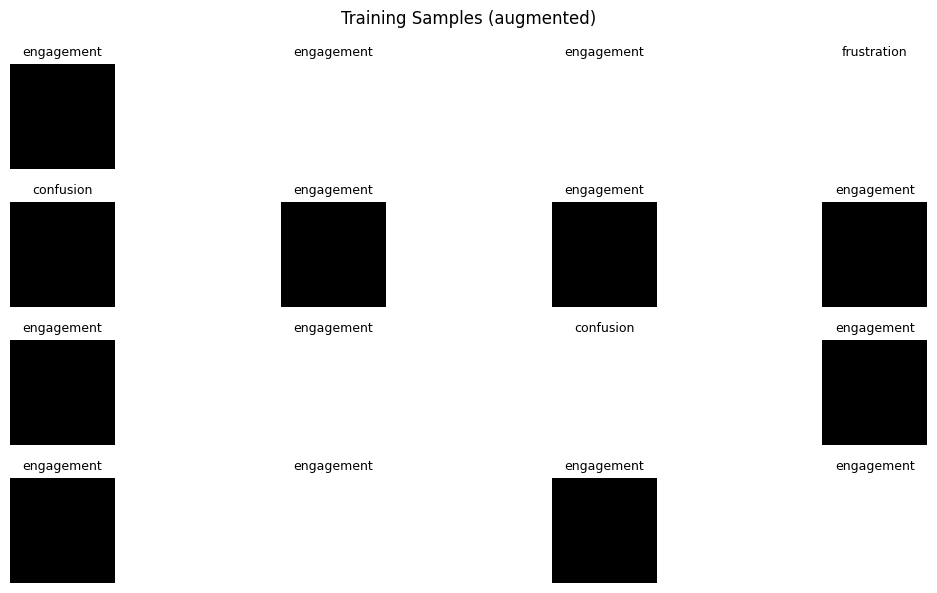

In [ ]:
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    'frames/Train', image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=True, seed=42)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'frames/Validation', image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    'frames/Test', image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', shuffle=False)

print(f"Classes: {train_ds.class_names}")

# Augmentation FIRST (on raw [0, 255] uint8 images), THEN rescale.
# RandomBrightness and RandomContrast work correctly on [0, 255] range.
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# Rescale to [0, 1] AFTER augmentation
rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (rescale(augment(x, training=True)), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# Compute class weights
train_labels = []
for _, labels in tf.keras.utils.image_dataset_from_directory(
    'frames/Train', image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', shuffle=False):
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

weights = compute_class_weight('balanced', classes=np.arange(4), y=train_labels)
class_weight = {i: w for i, w in enumerate(weights)}
print(f"Class weights: {class_weight}")

# Sample visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(16, len(images))):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().clip(0, 1))
        cls_idx = tf.argmax(labels[i]).numpy()
        plt.title(CLASS_NAMES[cls_idx], fontsize=9)
        plt.axis('off')
plt.suptitle('Training Samples (augmented)')
plt.tight_layout()
plt.show()

### Cell 5 — Model Architecture
MobileNetV2 (frozen) + GlobalAveragePooling2D + Dense(128, relu) + Dense(4, softmax)

Internal `Rescaling` layer converts [0,1] input to [-1,1] for MobileNetV2 compatibility.

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3), name='input')
x = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0)(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(4, activation='softmax', name='output')(x)

model = tf.keras.Model(inputs, x)
model.summary()
print(f"\nTrainable params: {sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 164,484


### Cell 6 — Phase 1: Train Head Only (base frozen)
Adam lr=1e-3, up to 15 epochs with early stopping.

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

callbacks_p1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=3, factor=0.5, verbose=1)
]

print("=== Phase 1: Frozen Base ===")
history_p1 = model.fit(
    train_ds, validation_data=val_ds, epochs=15,
    class_weight=class_weight, callbacks=callbacks_p1
)
print(f"\nBest val_accuracy: {max(history_p1.history['val_accuracy']):.4f}")

=== Phase 1: Frozen Base ===
Epoch 1/15
2033/2949 ━━━━━━━━━━━━━━━━━━━━ 16:12 1s/step - accuracy: 0.1559 - auc: 0.5009 - loss: 1.4589

KeyboardInterrupt: 

### Cell 7 — Phase 2: Unfreeze Last 3 Layers + Fine-Tune
Adam lr=1e-4 (10x lower), up to 15 more epochs.

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable params after unfreeze: {trainable_count:,}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=3, factor=0.5, verbose=1)
]

print("=== Phase 2: Fine-Tuning ===")
history_p2 = model.fit(
    train_ds, validation_data=val_ds, epochs=15,
    class_weight=class_weight, callbacks=callbacks_p2
)
print(f"\nBest val_accuracy: {max(history_p2.history['val_accuracy']):.4f}")

### Cell 8 — Evaluation
Training curves, confusion matrix, classification report.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_histories(history_p1, history_p2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hist['loss'], label='Train'); axes[0].plot(hist['val_loss'], label='Val')
axes[0].axvline(len(history_p1.history['loss']), color='gray', ls='--', label='Phase 2')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(hist['accuracy'], label='Train'); axes[1].plot(hist['val_accuracy'], label='Val')
axes[1].axvline(len(history_p1.history['accuracy']), color='gray', ls='--', label='Phase 2')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(hist['auc'], label='Train'); axes[2].plot(hist['val_auc'], label='Val')
axes[2].axvline(len(history_p1.history['auc']), color='gray', ls='--', label='Phase 2')
axes[2].set_title('AUC'); axes[2].legend()

plt.suptitle('Training History (Phase 1 + Phase 2)')
plt.tight_layout(); plt.show()

# Predictions on test set
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())
y_true = np.array(y_true); y_pred = np.array(y_pred)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)'); plt.tight_layout(); plt.show()

test_acc = np.mean(y_true == y_pred)
print(f"\nTest accuracy: {test_acc:.4f} (random baseline: 25%)")

### Cell 9 — ONNX Export & Verification

In [ ]:
import tf2onnx
import onnxruntime as ort

input_sig = [tf.TensorSpec(shape=[1, 224, 224, 3], dtype=tf.float32, name='input')]
model_proto, _ = tf2onnx.convert.from_keras(
    model, input_signature=input_sig, opset=15, output_path='cv_model.onnx')

file_size = os.path.getsize('cv_model.onnx') / 1e6
print(f"Exported: cv_model.onnx ({file_size:.1f} MB)")
assert file_size < 20, f"Model too large: {file_size:.1f} MB"

session = ort.InferenceSession('cv_model.onnx')
inp_name = session.get_inputs()[0].name
print(f"Input:  name='{inp_name}', shape={session.get_inputs()[0].shape}")
print(f"Output: shape={session.get_outputs()[0].shape}")

dummy = np.random.rand(1, 224, 224, 3).astype(np.float32)
result = session.run(None, {inp_name: dummy})
print(f"Output shape: {result[0].shape}, sum: {result[0].sum():.4f}")
assert result[0].shape == (1, 4), f"Wrong shape: {result[0].shape}"
assert abs(result[0].sum() - 1.0) < 0.01, "Softmax doesn't sum to 1"

keras_out = model.predict(dummy)
max_diff = np.abs(keras_out - result[0]).max()
print(f"Keras vs ONNX max diff: {max_diff:.8f}")
assert max_diff < 1e-4, f"Parity failed: {max_diff}"
print("\nAll checks passed!")

print("\n" + "="*50)
print("P-CV2 INTEGRATION SNIPPET:")
print("="*50)
print('''import onnxruntime as ort, numpy as np, cv2
session = ort.InferenceSession('cv_model.onnx')
face = cv2.resize(face_bgr, (224, 224))
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
inp = (face.astype(np.float32) / 255.0)[np.newaxis]
probs = session.run(None, {'input': inp})[0][0]
# [boredom, confusion, engagement, frustration]
# attention_score = probs[2], boredom = probs[0]
# disengagement = probs[1] + probs[3]''')

### Model Card — `cv_model.onnx`

| Property | Value |
|---|---|
| **File** | `cv_model.onnx` |
| **Input name** | `input` |
| **Input shape** | `[1, 224, 224, 3]` — float32, RGB |
| **Input format** | RGB face crop, `pixel_value / 255.0` (range [0, 1]) |
| **Output shape** | `[1, 4]` — float32 softmax probabilities |
| **Output order** | `[boredom, confusion, engagement, frustration]` (alphabetical) |
| **Label mapping** | `attention = output[2]`, `boredom = output[0]`, `disengagement = output[1]+output[3]` |
| **Fatigue** | NOT from this model — EAR/PERCLOS in P-CV2 |
| **Framework** | ONNX opset 15, `onnxruntime` |
| **Size** | ~9 MB |